<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [3]:
# Check for GPU
!nvidia-smi

'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


In [1]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device


2.11.0+cpu


'cpu'

## 1. What are 3 areas in industry where computer vision is currently being used?

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [ ]:
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data = datasets.MNIST(train=True,
                            root="data",
                            download=True,
                            transform=ToTensor(),
                            target_transform=None) 

test_data = datasets.MNIST(train=True,
                           root="data",
                           download=True,
                           transform=ToTensor())

class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 6. Visualize at least 5 different samples of the MNIST training dataset.

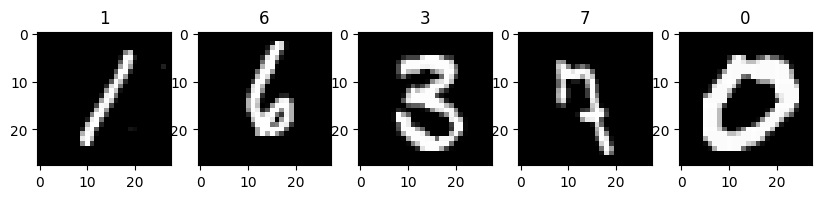

In [21]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10))

for i in range(1, 6):

    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    image, label = train_data[random_idx]

    fig.add_subplot(1, 5, i)
    plt.imshow(image.squeeze(), cmap="grey")
    plt.title(label)




## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [52]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=32)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [76]:
from torch import nn

class MNISTV2(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):

        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )
    
    def forward(self, x):

        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)

        return x

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [77]:
from helper_functions import accuracy_fn

epochs = 5

train_loss, train_acc = 0, 0


image, label = train_data[0]

model = MNISTV2(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

for epoch in range(1, epochs + 1):

    print(f"Epoch {epoch}\n-------")

    for X, y in train_dataloader:

        # 1. Forward Pass
        y_pred = model(X)

        # 2. Calculate Loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # 3. Zero Grad optimizers
        optimizer.zero_grad()

        # 4. Backpropogate
        loss.backward()

        # 5. Update parameters
        optimizer.step()
    
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)
    print(f"Train Loss: {train_loss:.5f} | Train Accuracy: {train_acc:.2f}%")

Epoch 1
-------
Train Loss: 0.27559 | Train Accuracy: 90.78%
Epoch 2
-------
Train Loss: 0.07592 | Train Accuracy: 97.73%
Epoch 3
-------
Train Loss: 0.05812 | Train Accuracy: 98.25%
Epoch 4
-------
Train Loss: 0.04889 | Train Accuracy: 98.52%
Epoch 5
-------
Train Loss: 0.04254 | Train Accuracy: 98.69%


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [ ]:
import random
from tqdm.auto import tqdm

pred_probs = []
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=5):

    test_samples.append(sample)
    test_labels.append(label)

model.eval()

test_samples[0].shape

with torch.inference_mode():

    for X, y in tqdm(test_dataloader, desc="Making predictions"):

        pred_logit = model(X)

        pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

        pred_probs.append(pred_prob.argmax(dim=1))

fig = plt.figure(figsize=(10, 10))

y_predictions = torch.cat(pred_probs)
    

Making predictions:   0%|          | 0/1875 [00:00<?, ?it/s]

tensor([5, 0, 4,  ..., 5, 6, 8])

<Figure size 1000x1000 with 0 Axes>

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

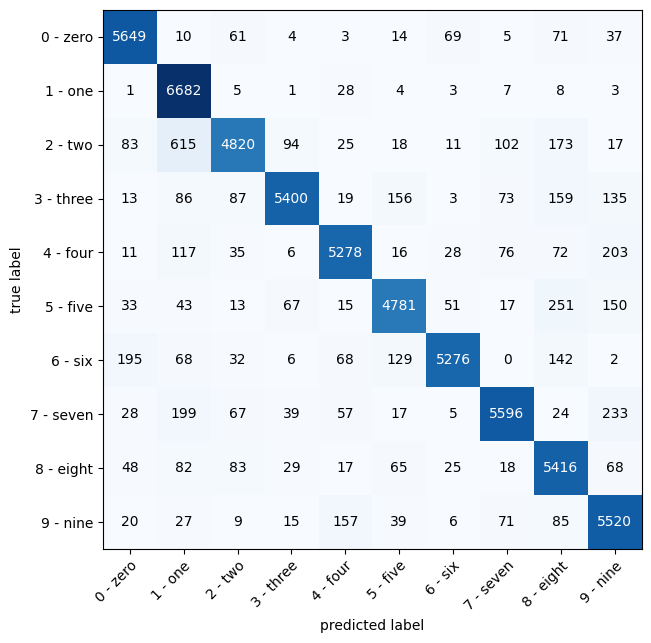

In [113]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_predictions,
                         target=test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [97]:
tens1 = torch.randn(size=(1, 3, 64, 64))

layer = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=1)

print(f"Before going through layer: {tens1}")
layer(tens1)
print(f"After going through layer: {tens1}")

Before going through layer: tensor([[[[-0.6808, -1.0233,  0.3369,  ...,  0.8147, -2.3690,  0.7661],
          [ 0.2917, -0.4987, -0.9944,  ..., -0.1127,  1.4783, -0.6301],
          [-0.3587, -0.4953, -0.6901,  ...,  1.6952, -0.2301, -0.6627],
          ...,
          [-0.8508,  1.1314,  0.6342,  ...,  1.3755,  2.5206, -1.3754],
          [-1.6598, -0.1570,  1.2879,  ...,  0.7615,  2.0904, -0.0444],
          [ 0.7390,  0.1961, -1.7626,  ...,  0.7504,  2.8448, -1.3288]],

         [[-0.6037, -0.8061,  0.6465,  ..., -0.9537, -0.9168, -0.6309],
          [-0.2237, -0.0222,  0.2843,  ...,  0.2891,  0.5149, -0.5304],
          [ 0.7067, -0.9908, -0.3501,  ...,  0.5678, -2.8254,  0.3840],
          ...,
          [-0.8192,  1.1915, -0.6876,  ...,  1.0519,  0.3016, -0.7197],
          [-1.3960, -0.1096,  1.5480,  ..., -0.7509, -1.1461, -0.1465],
          [ 0.9745,  1.1940,  1.5708,  ..., -0.9513, -0.1154, -0.2182]],

         [[ 0.8475, -1.0651,  0.1387,  ...,  2.3590,  0.2224, -0.2664],
  

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?